# Experiment 3 — Attention and Cued Items

**Goal.** Reproduce Bays Fig 3 (cued/uncued error distributions, variance, kurtosis) using a **biologically motivated alternative** to gain modulation: cueing recruits the subpopulation of neurons most informative about the cued location, and that subpopulation does *all* the work — encoding the cued and uncued items alike.

---


1. The cue identifies a location (by convention, location 0).
2. We rank all M neurons by their **sharpness at location 0** — concretely, the variance of their tuning curve f_{n,0}(θ) along the orientation grid. Neurons with sharper (narrower) tuning have larger swings and so larger variance; neurons with broad, flat tuning have small variance.
3. The top **M/l** neurons (where l is the set size) are the *recruited subpopulation* I_c. Every other neuron is silent for the trial — they are not in the picture at all.
4. The recruited neurons compute their pre-DN response normally, multiplying tuning across **all l locations** (cued and uncued):
$$r_n^{\text{pre}}(S, \theta) = \prod_{k \in S} g_{n,k}(\theta_k), \quad n \in I_c$$



In [46]:
# Setup
import sys
from pathlib import Path
import time
import datetime

PROJECT_ROOT = str(Path.cwd().parents[1])
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# The Bays cued engine lives in the modules; all circular metrics AND the von
# Mises KDE come from the central metrics module (single source of truth).
from core.population import Population, bays_run_trials_cued
from core.metrics import (
    circular_error,
    circular_variance_fisher,
    circular_kurtosis_fisher,
    circular_moments,
    vonmises_kde,
)
from core.decoder.ml_decoder import decode as ml_decode

# Figure-3 results live under this notebook's folder (bays_2014/result_data).
RESULT_BASE = Path.cwd() / 'result_data'
RESULT_BASE.mkdir(exist_ok=True)

print(f'Project root: {PROJECT_ROOT}')


Project root: /Users/yashbharti/Desktop/Research/mphil/mixed_selectivity_pfc_v0.1/equivalence_model_v0.1


## Experiment Control

In [47]:
# === EXPERIMENT CONTROL (the only M / DISTRIBUTION / MODEL knob) ===
M            = 1000                # 100 / 1000 / 10000
DISTRIBUTION = 'sparse_sharp'     # 'folded_normal' | 'gamma' | 'sparse_sharp'
MODEL        = 'gp'                # 'gp' | 'vm' | 'bays'  (the fitted model)

# sparse_sharp knobs (ignored unless DISTRIBUTION == 'sparse_sharp')
N_HIGH          = 1
HIGH_MULTIPLIER = 3.0

assert DISTRIBUTION in ('folded_normal', 'gamma', 'sparse_sharp'), DISTRIBUTION
assert MODEL in ('gp', 'vm', 'bays'), MODEL

# --- ONE shared output directory for this run (mirrors Experiment 2) ---
#   result_data / experiment_3 / <date> / <distribution>_<size>_<model> / <time>
EXPERIMENT_TAG = 'experiment_3'
_date = datetime.datetime.now().strftime('%Y%m%d')
_time = datetime.datetime.now().strftime('%H%M%S')
OUTPUT_DIR = (RESULT_BASE / EXPERIMENT_TAG / _date /
              f'{DISTRIBUTION}_{M}_{MODEL}' / _time)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('=== Experiment control (global) ===')
print(f'  M            = {M}')
print(f'  DISTRIBUTION = {DISTRIBUTION!r}')
print(f'  MODEL        = {MODEL!r}')
if DISTRIBUTION == 'sparse_sharp':
    print(f'  N_HIGH={N_HIGH}  HIGH_MULTIPLIER={HIGH_MULTIPLIER}')
print(f'  OUTPUT_DIR   = {OUTPUT_DIR}')


=== Experiment control (global) ===
  M            = 1000
  DISTRIBUTION = 'sparse_sharp'
  MODEL        = 'gp'
  N_HIGH=1  HIGH_MULTIPLIER=3.0
  OUTPUT_DIR   = /Users/yashbharti/Desktop/Research/mphil/mixed_selectivity_pfc_v0.1/equivalence_model_v0.1/experiments/bays_2014/result_data/experiment_3/20260806/sparse_sharp_1000_gp/153838


In [48]:
# === Fixed configuration (not swept) ===
N_THETA   = 128        # orientation grid resolution
T_D       = 0.1        # decoding window, s
SIGMA_SQ  = 1e-6       # DN semi-saturation constant
SET_SIZES = [2, 4, 8]  # cued experiment: l = 1 has no uncued condition
CUE_RATIO = 3.0        # cued item probed 3x as often as each uncued item
SEED      = 42

print(f'N_THETA={N_THETA}, T_d={T_D}s, set sizes={SET_SIZES}, cue ratio={CUE_RATIO}')


N_THETA=128, T_d=0.1s, set sizes=[2, 4, 8], cue ratio=3.0


## Model Framework

In [49]:
# === Model dispatcher + cued/uncued forward path ===
# build_population dispatches on MODEL (gp / vm / bays) exactly like Experiment
# 2. The cued/uncued asymmetry comes from *recruitment*: the top M/l neurons by
# tuning sharpness at the cued location (location 0) get an attentional gain
# alpha; Population.run_trials then handles DN + Poisson + ML decode. Note that
# recruitment only bites when tuning is heterogeneous across locations (true
# for gp and for vm with per-location widths); a homogeneous 'bays' population
# has identical tuning everywhere, so MODEL='bays' as the *fitted* model is
# degenerate here (it is the reference, generated separately below).

def build_population(width, cv, seed, *, n_locations):
    """Population at the chosen MODEL / DISTRIBUTION. `width` is the fit's free
    width parameter: for gp it is a GP lengthscale (omega = width**2); for
    vm / bays it is omega directly."""
    omega = width ** 2 if MODEL == 'gp' else width
    return Population(
        M=M, n_theta=N_THETA, omega=omega, tuning_type=MODEL,
        n_locations=n_locations, seed=seed,
        lengthscale_variability=cv, gain_variability=0.0,
        method=DISTRIBUTION, n_high=N_HIGH, high_multiplier=HIGH_MULTIPLIER,
    )


def recruited_mask_at_loc0(pop, set_size):
    """Top M/l neurons by tuning sharpness (variance) at location 0."""
    sharpness = pop.f[:, 0, :].var(axis=1)
    mask = np.zeros(pop.N, dtype=bool)
    mask[np.argsort(-sharpness)[: pop.N // set_size]] = True
    return mask


def gp_cued_uncued_errors(pop, set_size, gamma, alpha, recruited_mask,
                          n_trials, seed):
    """Cued and uncued error pools from ONE population, via the unified
    Population.run_trials engine (same seed-offset scheme as before)."""
    active = tuple(range(set_size))
    err_c = pop.run_trials(
        n_trials=n_trials, gamma=gamma, T_d=T_D, set_size=set_size,
        sigma_sq=SIGMA_SQ, rng=np.random.RandomState(seed + set_size * 1000),
        active_locations=active, probe_cued=True,
        alpha=alpha, recruited_mask=recruited_mask,
    )
    err_u = pop.run_trials(
        n_trials=n_trials, gamma=gamma, T_d=T_D, set_size=set_size,
        sigma_sq=SIGMA_SQ,
        rng=np.random.RandomState(seed + set_size * 1000 + 500_000),
        active_locations=active,
        probe_cued=(False if set_size > 1 else None),
        alpha=alpha, recruited_mask=recruited_mask,
    )
    return err_c, err_u


def gp_forward(width, gamma_per_neuron, cv, alpha, set_size, n_trials, seed=0):
    """Model forward: build pop at MODEL -> recruit at cued loc -> cued/uncued
    errors. Returns (err_cued, err_uncued), each length n_trials."""
    pop_local = build_population(width, cv, seed, n_locations=max(SET_SIZES))
    recruited_mask = recruited_mask_at_loc0(pop_local, set_size)
    return gp_cued_uncued_errors(
        pop_local, set_size=set_size, gamma=gamma_per_neuron, alpha=alpha,
        recruited_mask=recruited_mask, n_trials=n_trials, seed=seed,
    )


print('Defined: build_population, recruited_mask_at_loc0, '
      'gp_cued_uncued_errors, gp_forward')


Defined: build_population, recruited_mask_at_loc0, gp_cued_uncued_errors, gp_forward


## Bays Reference (cued) — generated, not cached

In [50]:
# === Bays cued/uncued synthetic reference (generated on the fly) ===
# Ground truth = Bays (2014) Experiment-2 ML values (Fig 3d). Generated via
# bays_run_trials_cued (core.population) -- the same parametric Bays model as
# Experiment 1, extended with the cued attentional gain. No cache load.
from scipy.optimize import least_squares

OMEGA_GEN_BAYS    = 0.49
GAMMA_TOTAL_GEN_B = 81.0
ALPHA_GEN_BAYS    = {2: 1.5, 4: 2.3, 8: 3.3}
M_BAYS_FIT        = M

SEED_FIT     = 42
N_DATA       = 10_000     # Bays synthetic trials per set size
N_TRIALS_FIT = 3_000      # model forward trials per validity
N_BINS       = 50
BIN_EDGES    = np.linspace(-np.pi, np.pi, N_BINS + 1)
GP_METHOD    = DISTRIBUTION

print(f'Ground truth: omega*={OMEGA_GEN_BAYS}, '
      f'gamma_total*={GAMMA_TOTAL_GEN_B} Hz, alpha*={ALPHA_GEN_BAYS}')

bays_data = {}
rng_data = np.random.RandomState(SEED_FIT)
for N in SET_SIZES:
    err_all, is_cued = bays_run_trials_cued(
        n_trials=N_DATA, set_size=N,
        omega=OMEGA_GEN_BAYS, gamma_total=GAMMA_TOTAL_GEN_B,
        T_d=T_D, alpha_cued=ALPHA_GEN_BAYS[N],
        cued_probe_ratio=CUE_RATIO, M_bays=M_BAYS_FIT, rng=rng_data,
    )
    err_c, err_u = err_all[is_cued], err_all[~is_cued]
    h_c, _ = np.histogram(err_c, bins=BIN_EDGES, density=True)
    h_u, _ = np.histogram(err_u, bins=BIN_EDGES, density=True)
    bays_data[N] = dict(err_cued=err_c, err_uncued=err_u,
                        hist_cued=h_c, hist_uncued=h_u)
    print(f'  l={N}: n_cued={len(err_c)}, n_uncued={len(err_u)}, '
          f'var_c={circular_variance_fisher(err_c):.3f}, '
          f'var_u={circular_variance_fisher(err_u):.3f}')

# Residual targets: Stage 1 = uncued only (all l concatenated);
#                   Stage 2 = joint cued + uncued at each l.
data_vector_stage1 = np.concatenate(
    [bays_data[N]['hist_uncued'] for N in SET_SIZES])
data_vector_stage2 = {
    N: np.concatenate([bays_data[N]['hist_cued'], bays_data[N]['hist_uncued']])
    for N in SET_SIZES
}
print(f'Stage 1 residual length: {len(data_vector_stage1)}; '
      f'Stage 2 per-l length: {len(data_vector_stage2[SET_SIZES[0]])}')


Ground truth: omega*=0.49, gamma_total*=81.0 Hz, alpha*={2: 1.5, 4: 2.3, 8: 3.3}
  l=2: n_cued=7553, n_uncued=2447, var_c=0.227, var_u=0.401
  l=4: n_cued=5058, n_uncued=4942, var_c=0.358, var_u=0.997
  l=8: n_cued=3006, n_uncued=6994, var_c=0.567, var_u=1.891
Stage 1 residual length: 150; Stage 2 per-l length: 100


## Two-Stage Fit

**Stage 1** fits the population physiology $(\lambda, \gamma, \text{CV})$ against the
*uncued* errors only (all set sizes, $\alpha = 1$). **Stage 2** locks those and fits the
attentional gain $\alpha_l$ — one number per set size — against the joint cued+uncued
histogram at that $l$. Both stages cache their result to disk (keyed on the model /
sampler / ground-truth / fit config) so a rerun skips the expensive optimisation.

In [51]:
# === STAGE 1: fit (lambda, gamma, CV) against UNCUED errors only ===
# Cache-aware: skips the 40-minute fit when a matching result is on disk.
# Cache key encodes ground-truth + fit-config + sampler, so any meaningful
# change forces a refit; pure plotting changes leave the cache valid.

from tqdm.auto import tqdm
import hashlib, json as _json

X0_STAGE1 = [1.0,  0.5,   0.5]    # was [1.0, 2.0, 0.5]
LO_STAGE1 = [0.2,  0.01,  0.05]   # was [0.2, 0.2, 0.05]
HI_STAGE1 = [2.0,  2.0,   3.0]    # was [2.0, 8.0, 3.0]
DIFF_STEP_STAGE1 = 0.05
_PENALTY_VALUE = 100.0

# ---- Cache key ----
_cache_key_dict = {
    'omega_gen':       OMEGA_GEN_BAYS,
    'gamma_total_gen': GAMMA_TOTAL_GEN_B,
    'alpha_gen':       ALPHA_GEN_BAYS,
    'M_bays':          M_BAYS_FIT,
    'N_data':          N_DATA,
    'cue_ratio':       CUE_RATIO,
    'T_d':             T_D,
    'M_gp':            M,
    'N_theta_gp':      N_THETA,
    'N_trials_fit':    N_TRIALS_FIT,
    'sigma_sq':        SIGMA_SQ,
    'set_sizes':       SET_SIZES,
    'seed_fit':        SEED_FIT,
    'gp_method':       GP_METHOD,
    'n_high':          N_HIGH,
    'high_multiplier': HIGH_MULTIPLIER,
    'x0_stage1':       X0_STAGE1,
    'lo_stage1':       LO_STAGE1,
    'hi_stage1':       HI_STAGE1,
    'diff_step':       DIFF_STEP_STAGE1,
    'n_bins':          N_BINS,
    'penalty':         _PENALTY_VALUE,
    'model':           MODEL,
    'stage':           'stage1_unified_api_v3',
}
_cache_key = hashlib.md5(
    _json.dumps(_cache_key_dict, sort_keys=True, default=str).encode()
).hexdigest()[:12]

CACHE_DIR  = RESULT_BASE / 'fit_cache'
CACHE_DIR.mkdir(exist_ok=True)
CACHE_FILE = CACHE_DIR / f'stage1_{_cache_key}.npz'

FORCE_REFIT_STAGE1 = False   # set True to bypass cache

if CACHE_FILE.exists() and not FORCE_REFIT_STAGE1:
    print(f'Stage 1 cache HIT: loading {CACHE_FILE.name}')
    cached = np.load(CACHE_FILE, allow_pickle=True)
    LAMBDA_LOCKED = float(cached['lambda_hat'])
    GAMMA_LOCKED  = float(cached['gamma_hat'])
    CV_LOCKED     = float(cached['cv_hat'])
    lambda_hat, gamma_hat, cv_hat = LAMBDA_LOCKED, GAMMA_LOCKED, CV_LOCKED
    STAGE1_COST = float(cached['final_cost'])
    omega_hat       = float(cached['omega_hat'])
    gamma_total_hat = float(cached['gamma_total_hat'])
    print(f'  Loaded: lambda={LAMBDA_LOCKED:.4f}, gamma={GAMMA_LOCKED:.4f}, '
          f'CV={CV_LOCKED:.4f}')
    print(f'  Cached cost: {float(cached["final_cost"]):.6f}, '
          f'evals: {int(cached["total_evals"])}, '
          f'failures: {int(cached["failures"])}')

else:
    if FORCE_REFIT_STAGE1:
        print('FORCE_REFIT_STAGE1 = True: refitting...')
    else:
        print(f'Stage 1 cache MISS (key {_cache_key}): running fit...')

    def forward_stage1(lambda_base, gamma_per_neuron, cv, seed=SEED_FIT):
        pred_hists = []
        try:
            for N in SET_SIZES:
                _, err_u = gp_forward(
                    lambda_base, gamma_per_neuron, cv,
                    alpha=1.0, set_size=N,
                    n_trials=N_TRIALS_FIT, seed=seed,
                )
                h_u, _ = np.histogram(err_u, bins=BIN_EDGES, density=True)
                pred_hists.append(h_u)
            return np.concatenate(pred_hists)
        except (np.linalg.LinAlgError, ValueError):
            return None

    _pbar = tqdm(desc='Stage 1 (lambda, gamma, CV)', unit='eval')
    _call_log = {'best_cost': np.inf, 'best_params': None, 'failures': 0}

    def residual_stage1(params):
        lam, gam, cv = params
        pred = forward_stage1(lam, gam, cv)
        if pred is None:
            _call_log['failures'] += 1
            res = np.full_like(data_vector_stage1, _PENALTY_VALUE)
            cost = 0.5 * float(np.sum(res ** 2))
        else:
            res = data_vector_stage1 - pred
            cost = 0.5 * float(np.sum(res ** 2))
            if cost < _call_log['best_cost']:
                _call_log['best_cost']   = cost
                _call_log['best_params'] = (lam, gam, cv)
        _pbar.update(1)
        _pbar.set_postfix(
            lam=f'{lam:.3f}', gam=f'{gam:.3f}', cv=f'{cv:.3f}',
            cost=f'{cost:.2f}', best=f'{_call_log["best_cost"]:.4f}',
            fails=_call_log['failures'],
        )
        return res

    print(f'Parameter bounds: lambda in [{LO_STAGE1[0]}, {HI_STAGE1[0]}], '
          f'gamma in [{LO_STAGE1[1]}, {HI_STAGE1[1]}], '
          f'CV in [{LO_STAGE1[2]}, {HI_STAGE1[2]}]')
    t0 = time.time()
    result_stage1 = least_squares(
        residual_stage1, x0=X0_STAGE1,
        bounds=(LO_STAGE1, HI_STAGE1),
        method='trf', diff_step=DIFF_STEP_STAGE1, verbose=0,
        max_nfev=200,
    )
    _pbar.close()

    lambda_hat, gamma_hat, cv_hat = result_stage1.x
    omega_hat       = lambda_hat ** 2 if MODEL == 'gp' else lambda_hat
    gamma_total_hat = gamma_hat * M
    LAMBDA_LOCKED = lambda_hat
    GAMMA_LOCKED  = gamma_hat
    CV_LOCKED     = cv_hat
    STAGE1_COST   = float(result_stage1.cost)

    # SAVE TO CACHE -- this MUST happen before the kernel restarts!
    np.savez(
        CACHE_FILE,
        lambda_hat=LAMBDA_LOCKED, gamma_hat=GAMMA_LOCKED, cv_hat=CV_LOCKED,
        omega_hat=omega_hat, gamma_total_hat=gamma_total_hat,
        final_cost=result_stage1.cost, total_evals=_pbar.n,
        failures=_call_log['failures'],
        cache_key_dict=_json.dumps(_cache_key_dict, sort_keys=True, default=str),
    )
    print(f'\nStage 1 cache SAVED: {CACHE_FILE.name}')

# ---- Print summary regardless ----
print(f'\n=== Stage 1 results ===')
print(f'  lambda_hat  = {lambda_hat:.4f}  '
      f'(omega_hat = {omega_hat:.4f},  Bays generating omega = {OMEGA_GEN_BAYS})')
print(f'  gamma_hat   = {gamma_hat:.4f}  '
      f'(gamma_total = {gamma_total_hat:.1f} Hz,  '
      f'Bays generating gamma_total = {GAMMA_TOTAL_GEN_B})')
print(f'  CV_hat      = {cv_hat:.4f}')
print(f'\nLocked for Stage 2: lambda={LAMBDA_LOCKED:.4f}, '
      f'gamma={GAMMA_LOCKED:.4f}, CV={CV_LOCKED:.4f}')


Stage 1 cache MISS (key 17385424061e): running fit...


Stage 1 (lambda, gamma, CV): 0eval [00:00, ?eval/s]

Parameter bounds: lambda in [0.2, 2.0], gamma in [0.01, 2.0], CV in [0.05, 3.0]

Stage 1 cache SAVED: stage1_17385424061e.npz

=== Stage 1 results ===
  lambda_hat  = 1.9845  (omega_hat = 3.9381,  Bays generating omega = 0.49)
  gamma_hat   = 0.2001  (gamma_total = 200.1 Hz,  Bays generating gamma_total = 81.0)
  CV_hat      = 0.5168

Locked for Stage 2: lambda=1.9845, gamma=0.2001, CV=0.5168


### Stage 2 — Attentional Gain $\alpha_l$ per Set Size

In [52]:
# === STAGE 2: fit alpha_l per set size at LOCKED (lambda, gamma, CV) ===
# Cache-aware: a single .npz holds all three alpha fits.

import hashlib, json as _json

X0_STAGE2 = [3.0]
LO_STAGE2 = [1.0]
HI_STAGE2 = [30.0]
DIFF_STEP_STAGE2 = 0.1

_cache_key_dict_s2 = {
    'lambda_locked': LAMBDA_LOCKED,
    'gamma_locked':  GAMMA_LOCKED,
    'cv_locked':     CV_LOCKED,
    'alpha_gen':     ALPHA_GEN_BAYS,
    'set_sizes':     SET_SIZES,
    'N_trials_fit':  N_TRIALS_FIT,
    'seed_fit':      SEED_FIT,
    'gp_method':     GP_METHOD,
    'n_high':        N_HIGH,
    'high_multiplier': HIGH_MULTIPLIER,
    'x0_stage2':     X0_STAGE2,
    'lo_stage2':     LO_STAGE2,
    'hi_stage2':     HI_STAGE2,
    'diff_step':     DIFF_STEP_STAGE2,
    'model':         MODEL,
    'stage':         'stage2_unified_api_v3',
}
_cache_key_s2 = hashlib.md5(
    _json.dumps(_cache_key_dict_s2, sort_keys=True, default=str).encode()
).hexdigest()[:12]
CACHE_FILE_S2 = CACHE_DIR / f'stage2_{_cache_key_s2}.npz'

FORCE_REFIT_STAGE2 = False

if CACHE_FILE_S2.exists() and not FORCE_REFIT_STAGE2:
    print(f'Stage 2 cache HIT: loading {CACHE_FILE_S2.name}')
    cached = np.load(CACHE_FILE_S2, allow_pickle=True)
    stage2_results = {}
    for N in SET_SIZES:
        stage2_results[N] = dict(
            alpha_hat  = float(cached[f'alpha_hat_{N}']),
            alpha_true = ALPHA_GEN_BAYS[N],
            cost       = float(cached[f'cost_{N}']),
        )
        print(f'  l={N}: alpha_hat={stage2_results[N]["alpha_hat"]:.3f} '
              f'(truth={ALPHA_GEN_BAYS[N]})')

else:
    print(f'Stage 2 cache MISS (key {_cache_key_s2}): running 3 fits...')

    def forward_stage2(alpha, set_size, seed=SEED_FIT):
        err_c, err_u = gp_forward(
            LAMBDA_LOCKED, GAMMA_LOCKED, CV_LOCKED,
            alpha=alpha, set_size=set_size,
            n_trials=N_TRIALS_FIT, seed=seed,
        )
        h_c, _ = np.histogram(err_c, bins=BIN_EDGES, density=True)
        h_u, _ = np.histogram(err_u, bins=BIN_EDGES, density=True)
        return np.concatenate([h_c, h_u])

    def make_residual_stage2(set_size):
        def residual(params):
            alpha = params[0]
            return data_vector_stage2[set_size] - forward_stage2(alpha, set_size)
        return residual

    print(f'Stage 2: locked lambda={LAMBDA_LOCKED:.4f}, '
          f'gamma={GAMMA_LOCKED:.4f}, CV={CV_LOCKED:.4f}\n')

    stage2_results = {}
    save_kwargs = {}
    for N in SET_SIZES:
        print(f'--- l = {N}  (Bays truth alpha = {ALPHA_GEN_BAYS[N]}) ---')
        t0 = time.time()
        result = least_squares(
            make_residual_stage2(N),
            x0=X0_STAGE2, bounds=(LO_STAGE2, HI_STAGE2),
            method='trf', diff_step=DIFF_STEP_STAGE2, verbose=0,
        )
        alpha_hat = float(result.x[0])
        stage2_results[N] = dict(
            alpha_hat  = alpha_hat,
            alpha_true = ALPHA_GEN_BAYS[N],
            cost       = result.cost,
        )
        save_kwargs[f'alpha_hat_{N}'] = alpha_hat
        save_kwargs[f'cost_{N}']      = result.cost
        print(f'  alpha_hat = {alpha_hat:.3f}  '
              f'(truth = {ALPHA_GEN_BAYS[N]}, abs error = '
              f'{abs(alpha_hat - ALPHA_GEN_BAYS[N]):.3f})')
        print(f'  cost = {result.cost:.4f}, time = {time.time()-t0:.1f}s')

    np.savez(
        CACHE_FILE_S2,
        cache_key_dict=_json.dumps(_cache_key_dict_s2, sort_keys=True, default=str),
        **save_kwargs,
    )
    print(f'\nStage 2 cache SAVED: {CACHE_FILE_S2.name}')

print('\n=== Stage 2 summary ===')
print(f'{"l":>3}  {"alpha_true":>11}  {"alpha_hat":>10}  '
      f'{"abs_err":>8}  {"cost":>8}')
for N in SET_SIZES:
    r = stage2_results[N]
    err = abs(r['alpha_hat'] - r['alpha_true'])
    print(f'{N:>3}  {r["alpha_true"]:>11.3f}  {r["alpha_hat"]:>10.3f}  '
          f'{err:>8.3f}  {r["cost"]:>8.4f}')


Stage 2 cache MISS (key 8cc1ebee8362): running 3 fits...
Stage 2: locked lambda=1.9845, gamma=0.2001, CV=0.5168

--- l = 2  (Bays truth alpha = 1.5) ---
  alpha_hat = 2.994  (truth = 1.5, abs error = 1.494)
  cost = 2.1347, time = 313.7s
--- l = 4  (Bays truth alpha = 2.3) ---
  alpha_hat = 2.809  (truth = 2.3, abs error = 0.509)
  cost = 1.4480, time = 387.7s
--- l = 8  (Bays truth alpha = 3.3) ---
  alpha_hat = 3.153  (truth = 3.3, abs error = 0.147)
  cost = 0.1743, time = 300.2s

Stage 2 cache SAVED: stage2_8cc1ebee8362.npz

=== Stage 2 summary ===
  l   alpha_true   alpha_hat   abs_err      cost
  2        1.500       2.994     1.494    2.1347
  4        2.300       2.809     0.509    1.4480
  8        3.300       3.153     0.147    0.1743


In [53]:
# === Log this fit to an accumulating CSV (one row per fit, UUID-tagged) ===
# Same scheme as Experiment 2: identifiers -> model parameters -> parameters
# used for THIS fit (inputs) -> fitted hats. Figure-3 hats are the Stage-1
# physiology (lambda, gamma, CV) plus the Stage-2 attentional gain alpha_l at
# each set size. Appends to one accumulating log; a fresh UUID per run.
import csv
import uuid

FIT_LOG_PATH = RESULT_BASE / EXPERIMENT_TAG / 'fit_log.csv'
FIT_LOG_PATH.parent.mkdir(parents=True, exist_ok=True)

fit_record = {
    # --- identifiers ---
    'uuid':             str(uuid.uuid4()),
    'datetime':         datetime.datetime.now().isoformat(timespec='seconds'),
    # --- model parameters ---
    'model':            MODEL,
    'M':                int(M),
    'distribution':     DISTRIBUTION,
    'n_high':           int(N_HIGH),
    'high_multiplier':  float(HIGH_MULTIPLIER),
    # --- parameters used for THIS fit (inputs; before the hats) ---
    'omega_gen_bays':   float(OMEGA_GEN_BAYS),
    'gamma_total_gen':  float(GAMMA_TOTAL_GEN_B),
    'alpha_gen':        repr({int(k): float(v) for k, v in ALPHA_GEN_BAYS.items()}),
    'cue_ratio':        float(CUE_RATIO),
    'M_bays':           int(M_BAYS_FIT),
    'T_d':              float(T_D),
    'sigma_sq':         float(SIGMA_SQ),
    'set_sizes':        repr(list(SET_SIZES)),
    'n_data':           int(N_DATA),
    'n_trials_fit':     int(N_TRIALS_FIT),
    'n_bins':           int(N_BINS),
    'seed_fit':         int(SEED_FIT),
    # --- fitted hats: Stage 1 physiology ---
    'lambda_hat':       float(lambda_hat),
    'gamma_hat':        float(gamma_hat),
    'cv_hat':           float(cv_hat),
    'omega_hat':        float(omega_hat),
    'gamma_total_hat':  float(gamma_total_hat),
    'stage1_cost':      float(STAGE1_COST),
}
# --- fitted hats: Stage 2 attentional gain, one column pair per set size ---
for N in SET_SIZES:
    fit_record[f'alpha_hat_{N}']  = float(stage2_results[N]['alpha_hat'])
    fit_record[f'alpha_cost_{N}'] = float(stage2_results[N]['cost'])

fieldnames = list(fit_record.keys())

# Guard: never silently append under a mismatched schema.
target_path = FIT_LOG_PATH
if FIT_LOG_PATH.exists() and FIT_LOG_PATH.stat().st_size > 0:
    with open(FIT_LOG_PATH, newline='') as f:
        existing_header = next(csv.reader(f), [])
    if existing_header != fieldnames:
        stamp = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
        target_path = FIT_LOG_PATH.with_name(f'fit_log_{stamp}.csv')
        print(f'WARNING: {FIT_LOG_PATH.name} has a different schema; '
              f'writing to {target_path.name} instead.')

write_header = not (target_path.exists() and target_path.stat().st_size > 0)
with open(target_path, 'a', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    if write_header:
        writer.writeheader()
    writer.writerow(fit_record)

n_rows = sum(1 for _ in open(target_path)) - 1
print(f'Logged fit {fit_record["uuid"]}  -> {target_path}  ({n_rows} record(s))')
print(f'  Stage 1: lambda={lambda_hat:.4f} gamma={gamma_hat:.4f} '
      f'CV={cv_hat:.4f} omega={omega_hat:.4f}')
print('  Stage 2: ' + '  '.join(
    f'alpha_{N}={stage2_results[N]["alpha_hat"]:.3f}' for N in SET_SIZES))


Logged fit 3954b4b5-9131-43fd-8c41-e7af774d70a1  -> /Users/yashbharti/Desktop/Research/mphil/mixed_selectivity_pfc_v0.1/equivalence_model_v0.1/experiments/bays_2014/result_data/experiment_3/fit_log.csv  (8 record(s))
  Stage 1: lambda=1.9845 gamma=0.2001 CV=0.5168 omega=3.9381
  Stage 2: alpha_2=2.994  alpha_4=2.809  alpha_8=3.153


## Figure — Model vs Bays overlay

Generating GP forward predictions at fitted parameters...
  l=2: alpha=2.994, var_c=0.135, var_u=0.199, kurt_c=14.886, kurt_u=9.210
  l=4: alpha=2.809, var_c=0.247, var_u=0.381, kurt_c=9.593, kurt_u=5.538
  l=8: alpha=3.153, var_c=0.843, var_u=1.358, kurt_c=2.275, kurt_u=0.841
Panel a peak=1.21, ymax=1.65, ticks=[0, 0.5, 1.0, 1.5]
Panel b variance range: [0.135, 1.891]
Panel c kurtosis range: [0.482, 14.886]

Saved figure to /Users/yashbharti/Desktop/Research/mphil/mixed_selectivity_pfc_v0.1/equivalence_model_v0.1/experiments/bays_2014/result_data/experiment_3/20260806/sparse_sharp_1000_gp/153838/bays_fig3_gp_overlay_M1000_sparse_sharp.png


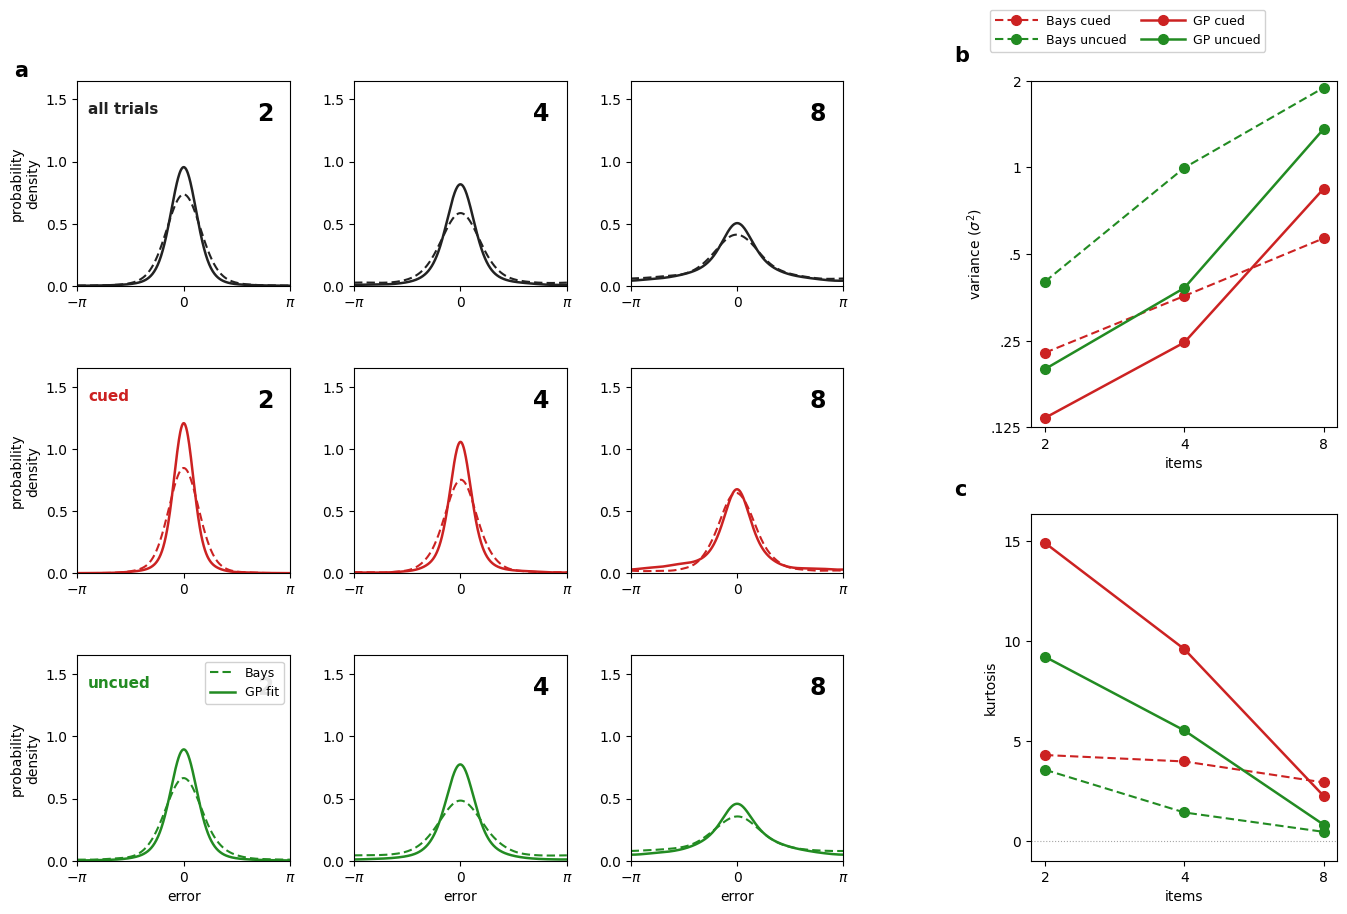

In [54]:
# === Plot Bays vs GP overlay (the headline comparison figure) ===
# Cued = red, uncued = green, all trials = black.
# Bays = dashed, GP = solid.

from pathlib import Path

# ---- 1. Generate the GP "fit" curves at the fitted parameters ----
# Kurtosis for Bays and GP both use circular_kurtosis_fisher (imported once
# at the top of the notebook), so the metric is identical across models.
print('Generating GP forward predictions at fitted parameters...')
gp_predictions = {}
for N in SET_SIZES:
    err_c, err_u = gp_forward(
        LAMBDA_LOCKED, GAMMA_LOCKED, CV_LOCKED,
        alpha=stage2_results[N]['alpha_hat'],
        set_size=N,
        n_trials=N_TRIALS_FIT * 3,
        seed=SEED_FIT,
    )
    p_c = CUE_RATIO / (CUE_RATIO + N - 1)
    n_c = int(round(p_c * len(err_c)))
    n_u = len(err_c) - n_c
    err_a = np.concatenate([err_c[:n_c], err_u[:n_u]])
    gp_predictions[N] = dict(
        err_all=err_a, err_cued=err_c, err_uncued=err_u,
        vc=circular_variance_fisher(err_c),
        vu=circular_variance_fisher(err_u),
        kc=circular_kurtosis_fisher(err_c),   # same function as Bays below
        ku=circular_kurtosis_fisher(err_u),   # same function as Bays below
    )
    print(f'  l={N}: alpha={stage2_results[N]["alpha_hat"]:.3f}, '
          f'var_c={gp_predictions[N]["vc"]:.3f}, '
          f'var_u={gp_predictions[N]["vu"]:.3f}, '
          f'kurt_c={gp_predictions[N]["kc"]:.3f}, '
          f'kurt_u={gp_predictions[N]["ku"]:.3f}')

# ---- 2. Plot ----
RED, GREEN, BLACK = '#CC2222', '#228B22', '#222222'
ROW_COLOR = {'err_all': BLACK, 'err_cued': RED, 'err_uncued': GREEN}

theta_smooth = np.linspace(-np.pi, np.pi, 500)
KAPPA_BY_ROW = {'err_all': 10.0, 'err_cued': 18.0, 'err_uncued': 10.0}

# Build 'err_all' for Bays (mixture at empirical 3:1 ratio).
for N in SET_SIZES:
    p_c = CUE_RATIO / (CUE_RATIO + N - 1)
    n_c = int(round(p_c * len(bays_data[N]['err_cued'])))
    n_u = len(bays_data[N]['err_cued']) - n_c
    bays_data[N]['err_all'] = np.concatenate([
        bays_data[N]['err_cued'][:n_c],
        bays_data[N]['err_uncued'][:n_u],
    ])

# Compute panel-a y-max from actual KDE peaks across both models.
peak = 0.0
for N in SET_SIZES:
    for k in ('err_all', 'err_cued', 'err_uncued'):
        for src in (bays_data[N], gp_predictions[N]):
            d = vonmises_kde(src[k], theta_smooth, KAPPA_BY_ROW[k])
            peak = max(peak, float(d.max()))

if   peak <= 1.10: PANEL_A_YMAX, PANEL_A_YTICKS = 1.10, [0, 0.5, 1.0]
elif peak <= 1.65: PANEL_A_YMAX, PANEL_A_YTICKS = 1.65, [0, 0.5, 1.0, 1.5]
elif peak <= 2.20: PANEL_A_YMAX, PANEL_A_YTICKS = 2.20, [0, 0.5, 1.0, 1.5, 2.0]
elif peak <= 3.30: PANEL_A_YMAX, PANEL_A_YTICKS = 3.30, [0, 1.0, 2.0, 3.0]
else:              PANEL_A_YMAX, PANEL_A_YTICKS = peak * 1.10, None
print(f'Panel a peak={peak:.2f}, ymax={PANEL_A_YMAX:.2f}, ticks={PANEL_A_YTICKS}')

fig = plt.figure(figsize=(14, 10))
outer = gridspec.GridSpec(1, 2, width_ratios=[2.5, 1], wspace=0.35,
                          left=0.06, right=0.96, bottom=0.08, top=0.86)
gs_a  = gridspec.GridSpecFromSubplotSpec(3, len(SET_SIZES),
            subplot_spec=outer[0], hspace=0.4, wspace=0.3)
gs_bc = gridspec.GridSpecFromSubplotSpec(2, 1,
            subplot_spec=outer[1], hspace=0.25)

# ---------- Panel a ----------
row_configs = [('err_all',    'all trials'),
               ('err_cued',   'cued'),
               ('err_uncued', 'uncued')]

first_ax = None
panel_a_legend_handles = None
for row, (key, label) in enumerate(row_configs):
    color = ROW_COLOR[key]
    for col, N in enumerate(SET_SIZES):
        ax = fig.add_subplot(gs_a[row, col])
        if first_ax is None: first_ax = ax

        d_bays = vonmises_kde(bays_data[N][key],     theta_smooth, KAPPA_BY_ROW[key])
        d_gp   = vonmises_kde(gp_predictions[N][key], theta_smooth, KAPPA_BY_ROW[key])
        h_bays, = ax.plot(theta_smooth, d_bays, color=color, lw=1.5,
                          ls='--', dashes=(4, 2), label='Bays')
        h_gp,   = ax.plot(theta_smooth, d_gp,   color=color, lw=1.8,
                          ls='-', label='GP fit')

        ax.set_xlim(-np.pi, np.pi); ax.set_ylim(0, PANEL_A_YMAX)
        ax.set_xticks([-np.pi, 0, np.pi])
        ax.set_xticklabels([r'$-\pi$', '0', r'$\pi$'])
        if PANEL_A_YTICKS is not None:
            ax.set_yticks(PANEL_A_YTICKS)
        if row == 2: ax.set_xlabel('error')

        ax.text(0.92, 0.90, f'{N}', transform=ax.transAxes,
                fontsize=17, fontweight='bold', va='top', ha='right')

        if col == 0:
            ax.set_ylabel('probability\ndensity')
            ax.text(0.05, 0.90, label, transform=ax.transAxes,
                    fontsize=11, fontweight='bold', va='top', color=color)

        if row == 2 and col == 0:
            panel_a_legend_handles = (h_bays, h_gp)

fig.axes[-len(SET_SIZES)].legend(panel_a_legend_handles, ['Bays', 'GP fit'],
                                  fontsize=9, loc='upper right',
                                  frameon=True, framealpha=0.9)

first_ax.text(-0.30, 1.10, r'$\mathbf{a}$', transform=first_ax.transAxes,
              fontsize=15, fontweight='bold', va='top')

ns = np.array(SET_SIZES, dtype=float)

# ---------- Panel b: variance ----------
# Variance stays on log2 x log2 -- it is strictly positive, spans a wide
# range, and Bays plots it this way in the original figure.
ax_b = fig.add_subplot(gs_bc[0])
vc_bays = [circular_variance_fisher(bays_data[N]['err_cued'])   for N in SET_SIZES]
vu_bays = [circular_variance_fisher(bays_data[N]['err_uncued']) for N in SET_SIZES]
vc_gp   = [gp_predictions[N]['vc'] for N in SET_SIZES]
vu_gp   = [gp_predictions[N]['vu'] for N in SET_SIZES]

l_bays_c, = ax_b.plot(ns, vc_bays, 'o', color=RED,   lw=1.5, ms=7,
                      ls='--', dashes=(4, 2), label='Bays cued')
l_bays_u, = ax_b.plot(ns, vu_bays, 'o', color=GREEN, lw=1.5, ms=7,
                      ls='--', dashes=(4, 2), label='Bays uncued')
l_gp_c,   = ax_b.plot(ns, vc_gp,   'o-',  color=RED,   lw=1.8, ms=7,
                      label='GP cued')
l_gp_u,   = ax_b.plot(ns, vu_gp,   'o-',  color=GREEN, lw=1.8, ms=7,
                      label='GP uncued')

ax_b.set_xscale('log', base=2); ax_b.set_yscale('log', base=2)
ax_b.set_xticks(SET_SIZES); ax_b.set_xticklabels([str(n) for n in SET_SIZES])

# Y-axis ticks: powers of 2 covering the data range, no minor ticks.
import math
all_v = np.array(vc_bays + vu_bays + vc_gp + vu_gp, dtype=float)
v_min, v_max = float(np.nanmin(all_v)), float(np.nanmax(all_v))
print(f'Panel b variance range: [{v_min:.3f}, {v_max:.3f}]')

lo_exp = int(math.floor(math.log2(max(v_min, 1e-3))))
hi_exp = int(math.ceil (math.log2(max(v_max, 1e-3))))
major_ticks = [2.0 ** e for e in range(lo_exp, hi_exp + 1)]

def _fmt_var(v):
    if v >= 1: return f'{v:g}'
    s = f'{v:g}'
    return s.lstrip('0') if s.startswith('0.') else s

ax_b.set_yticks(major_ticks)
ax_b.set_yticklabels([_fmt_var(t) for t in major_ticks])
# Suppress minor ticks; the major ticks above are already deliberate.
ax_b.yaxis.set_minor_locator(plt.NullLocator())
ax_b.set_ylim(2.0 ** lo_exp, 2.0 ** hi_exp)

ax_b.set_xlabel('items'); ax_b.set_ylabel(r'variance ($\sigma^2$)')
ax_b.text(-0.25, 1.10, r'$\mathbf{b}$', transform=ax_b.transAxes,
          fontsize=15, fontweight='bold', va='top')

# ---------- Panel c: kurtosis ----------
# Linear y-axis (was log2). Circular kurtosis is ~0 for both the von Mises
# (normal) and uniform distributions, so values genuinely approach -- and
# can cross -- zero at high load. Log2 with a 0.25 floor hid the full
# picture; linear with a y=0 reference makes it visible.
ax_c = fig.add_subplot(gs_bc[1])
kc_bays = [circular_kurtosis_fisher(bays_data[N]['err_cued'])   for N in SET_SIZES]
ku_bays = [circular_kurtosis_fisher(bays_data[N]['err_uncued']) for N in SET_SIZES]
kc_gp   = [gp_predictions[N]['kc'] for N in SET_SIZES]
ku_gp   = [gp_predictions[N]['ku'] for N in SET_SIZES]

ax_c.plot(ns, kc_bays, 'o', color=RED,   lw=1.5, ms=7, ls='--', dashes=(4, 2))
ax_c.plot(ns, ku_bays, 'o', color=GREEN, lw=1.5, ms=7, ls='--', dashes=(4, 2))
ax_c.plot(ns, kc_gp,   'o-', color=RED,   lw=1.8, ms=7)
ax_c.plot(ns, ku_gp,   'o-', color=GREEN, lw=1.8, ms=7)

# Reference line at kurtosis = 0 (circular normal AND uniform both sit here).
ax_c.axhline(0, color='gray', lw=0.8, ls=':', alpha=0.7, zorder=0)

# Auto y-limits with padding so we see the full range, including negative.
all_k = np.array(kc_bays + ku_bays + kc_gp + ku_gp, dtype=float)
k_min, k_max = float(np.nanmin(all_k)), float(np.nanmax(all_k))
k_pad = max(0.1, 0.10 * (k_max - k_min))
ax_c.set_ylim(min(k_min - k_pad, -0.1), k_max + k_pad)

ax_c.set_xscale('log', base=2)   # x stays log2 to match panel b
ax_c.set_xticks(SET_SIZES); ax_c.set_xticklabels([str(n) for n in SET_SIZES])

# Linear y ticks chosen automatically from the data range.
ax_c.yaxis.set_major_locator(plt.MaxNLocator(nbins=4, steps=[1, 2, 2.5, 5, 10]))
ax_c.yaxis.set_minor_locator(plt.NullLocator())

ax_c.set_xlabel('items'); ax_c.set_ylabel('kurtosis')
ax_c.text(-0.25, 1.10, r'$\mathbf{c}$', transform=ax_c.transAxes,
          fontsize=15, fontweight='bold', va='top')

print(f'Panel c kurtosis range: [{k_min:.3f}, {k_max:.3f}]')

# Shared legend for b and c, above the column.
fig.legend(handles=[l_bays_c, l_bays_u, l_gp_c, l_gp_u],
           loc='center', bbox_to_anchor=(0.81, 0.91),
           fontsize=9, frameon=True, framealpha=0.9,
           ncol=2, columnspacing=1.2, handlelength=3.5, handletextpad=0.6)



out_path = OUTPUT_DIR / f'bays_fig3_gp_overlay_M{M}_{DISTRIBUTION}.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
print(f'\nSaved figure to {out_path}')
plt.show()
